# Preprocessing: BalanceCorpus gesture, speech, and sway

This notebook does the signal conditioning for the coupling analysis and saves reusable files to disk. Nothing here answers a scientific question. It turns the raw recordings into clean, aligned, analysis-ready series so that `analysisv1.ipynb` can focus on the actual method (EMD, then Hilbert power, then coupling against a chance baseline).

Inputs (read from `DATA_ROOT`):

- `gyroscope.csv`: body-sway gyroscope for all pairs and trials. Columns include `group_name`, `trial_number`, `time`, an `AngleX` tilt angle, and an `AsX`angular speed.
- `metadata.csv`: per-trial information, including `clue_giver_condition`.
- `TS_acoustics/env_*.csv`: the speech amplitude envelope per trial. We use the
  `envelope_change` column as the speech signal.
- `TS_acoustics/f0_*.csv`: the fundamental frequency (F0) per trial, used to find
  the voiced stretches.
- `gestureclassifications/analysis/kinematic_features.csv`: one row per detected
  gesture, with kinematic features.

Outputs (written to `OUT_DIR`):

- `aligned_{pair}_{trial}.csv`: speech envelope and body sway on one shared time
  axis. Columns are `time, envelope, sway_speed, sway_lean`. Stored at full
  length, not edge-trimmed.
- `iaaft_{pair}_{trial}_n{N}.csv`: N surrogate copies of the edge-trimmed
  sway-lean, used as the chance baseline for the coupling test. One column per
  surrogate, plus a `time` column, so you can open the file and plot any
  surrogate directly.
- `voicing.csv`: onset and offset (in seconds) of every voiced stretch, per trial.
- `gestures.csv`: cue-giver gestures only, with `onset` and `offset` already
  parsed out of the id, plus kinematics.
- `trials.csv`: one row per surviving trial, with `pair`, `trial`, `condition`,
  lengths, and file names.
- `params.json`: the conditioning settings, so the analysis reads them back
  instead of hard-coding them.

On trimming: EMD and the Hilbert amplitude are unreliable at the very
start and end of a signal, because the method has no data beyond the edges to
work with, so the first and last stretch of the result is distorted. The smoothing is also based on fewer samples at the edges. Edge trim means cutting a fixed amount of time (`EDGE_SECONDS`, here 1 second) off each end so the coupling is measured only on the trustworthy middle of the trial.

Note that:

- The aligned file is stored at full length, not trimmed. The analysis runs EMD on the whole envelope and only then drops the edge samples. The surrogates are made here but at the trimmed length. Making surrogates (IAAFT) is the slow step, so it belongs in preprocessing. But the analysis compares against the edge-trimmed lean, so the surrogates must be built at that same trimmed length. Alignment, the edge trim, and surrogate go together.

In [201]:
import os, glob, json, re                     # files, path matching, params.json, id parsing
import numpy as np                            # numerics
import pandas as pd                           # tables and csv reading/writing
# from scipy.ndimage import uniform_filter1d    # fast moving average, used for smoothing
import matplotlib.pyplot as plt               # only for the two teaching figures below
from scipy.signal import savgol_filter        # for smoothing the sway speed and lean

## 0. Parameters and paths

These are the only settings for the whole conditioning stack. They are written
to `params.json` at the end so the analysis notebook stays in sync.

- `FS`: the sampling rate we treat the envelope grid as, in Hz. The gyro is
  interpolated onto the envelope's timestamps, so `FS` is really the envelope's
  rate. It sets the smoothing window size and the edge-trim length.
- `SMOOTHING_SECONDS`: width of the smoothing window applied to sway, in
  seconds.
- `EDGE_SECONDS`: how many seconds to cut from each end of a trial before
  measuring coupling (see the edge-trim note in the intro). We do not cut the
  aligned file here, because the analysis needs the full envelope for EMD, but we
  record the value and build the surrogates at the trimmed length.
- `N_SURROGATES` and `N_ITER`: the number of IAAFT surrogates per trial and the
  refinement iterations. More surrogates give better-resolved p-values but run
  slower.

In [202]:
# conditioning parameters (single source of truth)
FS                = 500.0          # envelope grid rate (Hz); gyro is resampled onto it
SMOOTHING_SECONDS = 0.05            # span window for sway (s)
EDGE_SECONDS      = 1.0            # trim per side downstream (s) to drop boundary artefacts
N_SURROGATES      = 50             # IAAFT surrogates per trial
N_ITER            = 100            # IAAFT refinement iterations
ENVELOPE_COLUMN   = 'envelope_change'   # if you want to take the raw envelope then 'envelope here' which column of the env_*.csv is the speech signal

#paths
DATA_ROOT = '../..'                 # holds gyroscope.csv, metadata.csv, TS_acoustics/, gestureclassifications/
OUT_DIR   = './intermediateoutput'  # where all preprocessed artefacts are written
os.makedirs(OUT_DIR, exist_ok=True)

print(f"Reading raw data from : {os.path.abspath(DATA_ROOT)}")
print(f"Writing artefacts to  : {os.path.abspath(OUT_DIR)}")

Reading raw data from : d:\Research_projects\TilburgMultiscaleSummerschool2026\Datasets\BalanceCorpus
Writing artefacts to  : d:\Research_projects\TilburgMultiscaleSummerschool2026\Datasets\BalanceCorpus\scripts\analysis_multiscaleintracoupling\intermediateoutput


## 1. Put speech envelope and body sway on one clock

Three things happen in `align_gyro_to_envelope`:

- Resample: the gyro arrives at its own uneven rate, so we linearly interpolate
  it onto the envelope's timestamps (the `FS`-Hz grid). After this, envelope and
  sway share one time axis and can be compared point by point.
- Unwrap: the raw tilt angle jumps between +180 and -180 degrees, which creates
  artificial cliffs. `np.unwrap` stitches those jumps back into a continuous
  line. We then subtract the median (the upright resting posture) and take the
  absolute value, giving `sway_lean`, how far the body leans from centre.
- Smooth: `SMOOTHING_SECONDS` over the uniform grid
  removes sensor jitter from both the angular speed (`sway_speed`) and the lean.

The gyro rows can arrive out of order, so we always sort by time before
unwrapping.

In [203]:
def parse_env_filename(path):
    """Turn an envelope filename into (pair, trial).

    Example: env_103_203_12_1.csv gives ('103_203', 12). The pair is the two
    speaker ids joined; the trial is the next field.
    """
    parts = os.path.basename(path.replace('\\', '/')).split('_')
    return f"{parts[1]}_{parts[2]}", int(parts[3])


def align_gyro_to_envelope(envtest, gyrotest, column=ENVELOPE_COLUMN,
                           fs=FS, smoothing_seconds=SMOOTHING_SECONDS):
    """Put the speech envelope and the gyro on one shared time grid.

    Returns (time, envelope, sway_speed, sway_lean), all sampled on the
    envelope's timestamps and clipped to the span the two recordings share.
    sway_speed is the smoothed absolute angular speed; sway_lean is the smoothed
    absolute tilt away from the upright resting posture.
    """
    # --- speech envelope: its values, plus a time axis in seconds ---
    envelope = envtest[column].to_numpy()
    envelope_time = envtest['time'].to_numpy().astype(float)
    # large steps between samples mean the column is in milliseconds, so divide
    # to get seconds (a real-second grid has tiny steps, e.g. 0.002)
    if np.median(np.diff(envelope_time)) > 0.5:
        envelope_time = envelope_time / 1000.0

    # --- gyro: build a seconds axis and sort, because rows can arrive shuffled ---
    gyro = gyrotest.copy()
    # seconds since this trial's first timestamp
    gyro['seconds'] = (pd.to_datetime(gyro['time']) - pd.to_datetime(gyro['time']).iloc[0]).dt.total_seconds()
    gyro = gyro.sort_values('seconds').reset_index(drop=True)   # time-order before unwrapping
    gyro_time = gyro['seconds'].to_numpy()

    # angular speed: the AsX column (its name may carry a unit, so match by prefix)
    angular_speed = gyro[next(c for c in gyro.columns if c.startswith('AsX'))].to_numpy()

    # tilt angle: the AngleX column, matched the same way
    angle = gyro[next(c for c in gyro.columns if c.startswith('AngleX'))].to_numpy()
    # undo the wrap at the angle limits so the trace is continuous, then measure
    # how far it sits from the upright posture (taken as the median angle)
    angle_unwrapped = np.degrees(np.unwrap(np.radians(angle)))
    lean_angle = np.abs(angle_unwrapped - np.median(angle_unwrapped))

    # --- keep only the time span the envelope and gyro have in common ---
    start = max(envelope_time[0], gyro_time[0])
    end   = min(envelope_time[-1], gyro_time[-1])
    keep = (envelope_time >= start) & (envelope_time <= end)
    time = envelope_time[keep]

    # --- resample the gyro onto the envelope grid, then smooth on that grid ---
    polyorder = 4
    window = max(polyorder + 1, int(smoothing_seconds * fs))
    window = min(window, len(time))
    if window % 2 == 0: # we need uneven window for the Savitzky-Golay filter
        window -= 1
    sway_speed = savgol_filter(np.abs(np.interp(time, gyro_time, angular_speed)), window, polyorder)
    sway_lean  = savgol_filter(       np.interp(time, gyro_time, lean_angle),      window, polyorder)

    return time, envelope[keep], sway_speed, sway_lean

In [204]:
# --- sanity-check the alignment on one example trial before running them all ---
gyro_all  = pd.read_csv(os.path.join(DATA_ROOT, 'gyroscope.csv'))    # all trials in one file
env_files = sorted(glob.glob(os.path.join(DATA_ROOT, 'TS_acoustics', 'env_*.csv')))
print(f"{len(env_files)} envelope files found")

EXAMPLE = 0                                                         # which env file to preview
pair, trial = parse_env_filename(env_files[EXAMPLE])
envtest  = pd.read_csv(env_files[EXAMPLE])                          # this trial's speech envelope
gyrotest = gyro_all[(gyro_all['group_name'] == pair) & (gyro_all['trial_number'] == trial)]  # its gyro rows

# align the two, then report the length so we can see they now match
time, envelope, sway_speed, sway_lean = align_gyro_to_envelope(envtest, gyrotest)
print(f"example {pair} trial {trial}: {len(time)} samples, {time[-1]-time[0]:.1f}s, "
      f"envelope and sway all length {len(envelope)}")

80 envelope files found
example 103_203 trial 12: 8666 samples, 17.3s, envelope and sway all length 8666


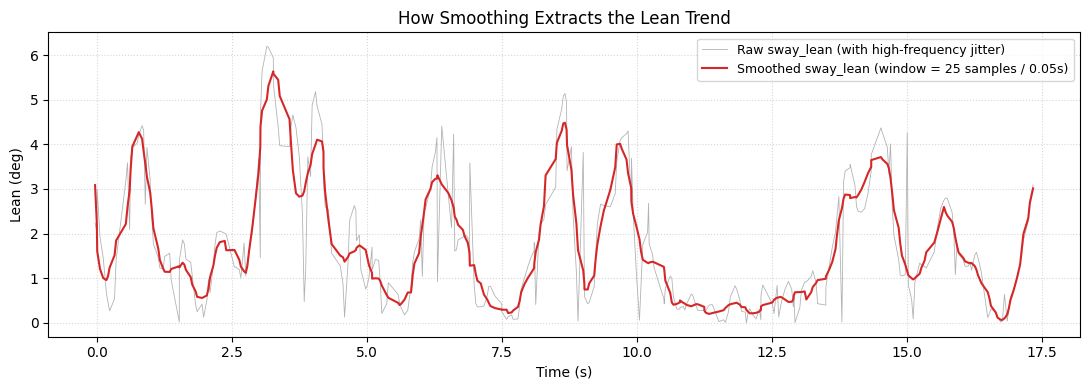

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

# --- 1. Signal Preparation & Unwrapping ---
gy = gyrotest.copy()
gy['seconds'] = (pd.to_datetime(gy['time']) - pd.to_datetime(gy['time']).iloc[0]).dt.total_seconds()
gy = gy.sort_values('seconds').reset_index(drop=True)
tt   = gy['seconds'].to_numpy()

# Extract and unwrap the angle to calculate raw lean
raw  = gy[next(c for c in gy.columns if c.startswith('AngleX'))].to_numpy()
unw  = np.degrees(np.unwrap(np.radians(raw)))
lean_raw = np.abs(unw - np.median(unw))  # This is your raw, jittery lean signal

# --- 2. What & How: Apply Smoothing directly to Lean ---
# (Assuming FS and SMOOTHING_SECONDS are defined in your workspace)
window      = max(1, int(SMOOTHING_SECONDS * FS))
lean_smooth = savgol_filter(lean_raw, window if window % 2 == 1 else window + 1, polyorder=4)  # Ensure window is odd

# --- 3. Plotting the Teaching Figure ---
fig, ax = plt.subplots(figsize=(11, 4))

# Plot raw lean in a light/thin style so the jitter is clear
ax.plot(tt, lean_raw, color='0.7', lw=0.6, label='Raw sway_lean (with high-frequency jitter)')

# Plot smoothed lean on top in a bold, solid color
ax.plot(tt, lean_smooth, color='C3', lw=1.5, 
        label=f'Smoothed sway_lean (window = {window} samples / {SMOOTHING_SECONDS}s)')

# Formatting
ax.set_xlabel('Time (s)')
ax.set_ylabel('Lean (deg)')
ax.set_title('How Smoothing Extracts the Lean Trend')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## 2. Voiced-segment table

This is plain file-to-table work. For each F0 file, a sample counts as voiced
when F0 is present (not missing). We find where the voiced state switches on and
off to get the onset and offset (in seconds) of every voiced stretch, then stack
them across all trials into one table.

In [206]:
def voicing_segments(f0_path):
    """Find the voiced stretches in one F0 file.

    Returns a table of onset and offset times in seconds. A sample is voiced when
    it has an F0 value; unvoiced samples are missing (NaN).
    """
    df = pd.read_csv(f0_path)
    t = df['time_ms'].to_numpy() / 1000.0            # milliseconds to seconds
    voiced = df['f0'].notna().to_numpy()             # True where F0 is present
    edges = np.diff(voiced.astype(int))              # +1 where voicing starts, -1 where it ends
    onsets  = t[1:][edges == 1]                      # times voicing starts
    offsets = t[1:][edges == -1]                     # times voicing ends
    if voiced[0]:  onsets  = np.r_[t[0], onsets]     # trial already voiced at the start
    if voiced[-1]: offsets = np.r_[offsets, t[-1]]   # trial still voiced at the end
    return pd.DataFrame({'onset': onsets, 'offset': offsets})


def parse_id_f0(path):
    """Turn an F0 filename into (pair, trial), same scheme as the envelope files."""
    parts = os.path.basename(path).split('_')
    return f"{parts[1]}_{parts[2]}", int(parts[3])

In [207]:
# build one voiced-segment table across every F0 file
f0_files = sorted(glob.glob(os.path.join(DATA_ROOT, 'TS_acoustics', 'f0_*.csv')))
rows = []
for fp in f0_files:
    pair, trial = parse_id_f0(fp)
    seg = voicing_segments(fp)                 # onset/offset for this trial
    seg['pair'], seg['trial'] = pair, trial    # tag every row with its trial
    rows.append(seg)

voicing = pd.concat(rows, ignore_index=True)   # stack all trials into one table
voicing.to_csv(os.path.join(OUT_DIR, 'voicing.csv'), index=False)
print(f"voicing.csv: {voicing.groupby(['pair','trial']).ngroups} trials, "
      f"{len(voicing)} voiced segments")
voicing.head()

voicing.csv: 80 trials, 2317 voiced segments


,onset,offset,pair,trial
0,1.345010,1.377082,103_203,12
1,1.401136,1.623634,103_203,12
2,1.669737,1.735885,103_203,12
3,1.848137,2.034554,103_203,12
4,2.359281,2.507613,103_203,12


## 3. Clean gesture table, with onset and offset columns

Also plain wrangling. We:

- parse `pair` and `trial` out of the gesture id,
- keep cue-giver gestures only, dropping any id that contains the guesser,
- pull each gesture's `onset` and `offset` out of the id with one regex, so later
  code never has to parse strings again.

The kinematic feature columns are carried through unchanged.

In [208]:
# load every detected gesture, then clean it into an analysis-ready table
gest = pd.read_csv(os.path.join(DATA_ROOT, 'gestureclassifications', 'analysis', 'kinematic_features.csv'))

# the gesture id encodes the trial, so split it to recover pair and trial
ids = gest['gesture_id'].str.split('_', expand=True)
gest['pair']  = ids[0] + '_' + ids[1]
gest['trial'] = ids[2].astype(int)

# keep only cue-giver gestures (drop any id that mentions the guesser)
gest = gest[gest['gesture_id'].str.contains('clueGiver')].copy()

# the id also ends with the gesture onset and offset; pull them out once here so
# the analysis never has to parse this string again
spans = gest['gesture_id'].str.extract(r'_Gesture_([\d.]+)_([\d.]+)$').astype(float)
gest['onset']  = spans[0]
gest['offset'] = spans[1]

gest.to_csv(os.path.join(OUT_DIR, 'gestures.csv'), index=False)
print(f"gestures.csv: {len(gest)} cue-giver gestures across "
      f"{gest.groupby(['pair','trial']).ngroups} trials")
gest[['gesture_id', 'pair', 'trial', 'onset', 'offset']].head()

gestures.csv: 604 cue-giver gestures across 77 trials


,gesture_id,pair,trial,onset,offset
0,103_203_12_1_20250113_152455_doughnut_board_cl...,103_203,12,0.80,6.77
1,103_203_12_1_20250113_152455_doughnut_board_cl...,103_203,12,7.80,10.33
2,103_203_12_1_20250113_152455_doughnut_board_cl...,103_203,12,14.07,17.40
3,103_203_12_1_20250113_152455_doughnut_board_cl...,103_203,12,0.80,6.63
4,103_203_12_1_20250113_152455_doughnut_board_cl...,103_203,12,7.80,10.33


## 4. IAAFT surrogates: the sway-lean chance baseline

To ask whether envelope power and sway lean are coupled more than expected by
chance, we compare the real coupling against surrogates. A surrogate is a
phase-randomised version of the lean that keeps its power spectrum and amplitude
distribution but scrambles the precise timing. IAAFT (iterative
amplitude-adjusted Fourier transform) is the standard way to build one.

One important detail: the analysis compares against the edge-trimmed lean, so the
surrogates must have that same length. We build them from `sway_lean` with
`EDGE_SECONDS` cut off each end. Each trial is seeded from its id so the result
is reproducible, and the surrogates are saved as a CSV (one column per
surrogate, plus a `time` column) so you can inspect and plot them directly. The
file is cached, so re-running does not repeat the slow step unless the trimmed
length has changed.

In [209]:
def iaaft(x, n_iter=N_ITER, rng=None):
    """Build one IAAFT surrogate of the series x.

    The surrogate keeps x's power spectrum and its set of amplitude values but
    scrambles the order in time, so it is a chance version of x. Two constraints
    are enforced by turns until they settle: match the spectrum, then match the
    amplitude values.
    """
    rng = rng or np.random.default_rng()
    n = len(x)
    amp_sorted = np.sort(x)                     # x's amplitude values, sorted small to large
    fft_mag = np.abs(np.fft.rfft(x))           # the power spectrum we want to keep
    surr = rng.permutation(x)                  # start from a random shuffle of x
    for _ in range(n_iter):
        # match the spectrum: keep the surrogate's phases, swap in x's magnitudes
        phases = np.angle(np.fft.rfft(surr))
        surr = np.fft.irfft(fft_mag * np.exp(1j * phases), n=n)
        # match the amplitudes: replace values by rank, so the k-th largest
        # surrogate value becomes the k-th largest value of x
        surr = amp_sorted[np.argsort(np.argsort(surr))]
    return surr


def make_surrogates(lean, pair, trial, time=None,
                    n_surrogates=N_SURROGATES, n_iter=N_ITER, out_dir=OUT_DIR):
    """Make n_surrogates IAAFT surrogates of lean and save them as a CSV.

    The CSV has one column per surrogate (surrogate_000, surrogate_001, ...) so
    each surrogate is a full time series you can open and plot directly. If a
    time array is passed it becomes the first column. On disk the shape is
    (n_samples rows) by (n_surrogates columns, plus the time column).

    To get back the (n_surrogates, n_samples) array the analysis works with:
        df = pd.read_csv(path)
        surr = df.drop(columns='time').to_numpy().T

    The file is cached per trial, so re-running does not repeat the slow IAAFT
    step unless the trimmed length has changed.
    """
    path = os.path.join(out_dir, f'iaaft_{pair}_{trial}_n{n_surrogates}.csv')

    # reuse the cached file if it already has the right shape
    if os.path.exists(path):
        cached = pd.read_csv(path)
        surr_cols = [c for c in cached.columns if c != 'time']
        if len(cached) == len(lean) and len(surr_cols) == n_surrogates:
            return cached[surr_cols].to_numpy().T

    # seed from the trial id so the same trial always gives the same surrogates
    seed = int(''.join(filter(str.isdigit, f'{pair}{trial}'))) % (2**32)
    rng = np.random.default_rng(seed)

    # one surrogate per row, giving the array shape (n_surrogates, n_samples)
    surr = np.array([iaaft(lean, n_iter=n_iter, rng=rng) for _ in range(n_surrogates)])

    # write with surrogates as columns so the file is easy to scan and plot
    out = pd.DataFrame(surr.T, columns=[f'surrogate_{i:03d}' for i in range(n_surrogates)])
    if time is not None:
        out.insert(0, 'time', time)            # first column, so every row has a timestamp
    # 6 significant figures keeps the file small and readable; it does not affect
    # the rank-based coupling test the analysis runs on these values
    out.to_csv(path, index=False, float_format='%.6g')
    return surr

## 5. Run the whole corpus and write the files

For every trial we:

- align the envelope and sway,
- look up the trial's condition,
- save the full aligned series,
- build IAAFT surrogates from the edge-trimmed lean.

Trials with too little gyro data, or too few samples to survive the edge trim,
are skipped and listed. A `trials.csv` manifest and `params.json` are written
last so the analysis can load everything in a few lines.

In [210]:
# run every trial: align it, save the aligned series, and save its surrogates
gyro_all = pd.read_csv(os.path.join(DATA_ROOT, 'gyroscope.csv'))
meta_all = pd.read_csv(os.path.join(DATA_ROOT, 'metadata.csv'))
env_files = sorted(glob.glob(os.path.join(DATA_ROOT, 'TS_acoustics', 'env_*.csv')))
edge = int(EDGE_SECONDS * FS)                  # edge-trim length, in samples

manifest, skipped = [], []
for env_path in env_files:
    pair, trial = parse_env_filename(env_path)
    envtest  = pd.read_csv(env_path)
    gyrotest = gyro_all[(gyro_all['group_name'] == pair) & (gyro_all['trial_number'] == trial)]
    if len(gyrotest) < 50:                      # too little gyro to be usable
        skipped.append((pair, trial, 'gyro<50')); continue

    # put speech and sway on one grid
    time, envelope, sway_speed, sway_lean = align_gyro_to_envelope(
        envtest, gyrotest, column=ENVELOPE_COLUMN, fs=FS, smoothing_seconds=SMOOTHING_SECONDS)
    if len(envelope) <= 2 * edge:               # nothing left after trimming both ends
        skipped.append((pair, trial, 'too_short')); continue

    # look up this trial's condition from the metadata
    m = meta_all[(meta_all['pair_id'] == pair) & (meta_all['trial_number'] == trial)]
    condition = m['clue_giver_condition'].iloc[0] if len(m) else np.nan

    # save the aligned series at FULL length (the analysis runs EMD on it, then trims)
    aligned_file = f'aligned_{pair}_{trial}.csv'
    pd.DataFrame({'time': time, f'{ENVELOPE_COLUMN}': envelope,
                  'sway_speed': sway_speed, 'sway_lean': sway_lean}
                 ).to_csv(os.path.join(OUT_DIR, aligned_file), index=False)

    # build the surrogates on the edge-trimmed lean, with its matching time axis,
    # so they line up with what the analysis correlates against
    lean_trim = sway_lean[edge:-edge]
    time_trim = time[edge:-edge]
    make_surrogates(lean_trim, pair, trial, time=time_trim,
                    n_surrogates=N_SURROGATES, n_iter=N_ITER, out_dir=OUT_DIR)

    # record what this trial produced, for the manifest
    manifest.append(dict(pair=pair, trial=trial, condition=condition,
                         n=len(envelope), n_trimmed=len(lean_trim),
                         aligned_file=aligned_file,
                         surrogate_file=f'iaaft_{pair}_{trial}_n{N_SURROGATES}.csv'))

# one manifest row per surviving trial
trials = pd.DataFrame(manifest)
trials.to_csv(os.path.join(OUT_DIR, 'trials.csv'), index=False)

# record the settings so the analysis reads them back instead of hard-coding them
params = dict(fs=FS, smoothing_seconds=SMOOTHING_SECONDS, edge_seconds=EDGE_SECONDS,
              n_surrogates=N_SURROGATES, n_iter=N_ITER, envelope_column=ENVELOPE_COLUMN)
with open(os.path.join(OUT_DIR, 'params.json'), 'w') as f:
    json.dump(params, f, indent=2)

print(f"wrote {len(trials)} trials to {OUT_DIR}")
if not trials.empty:
    print(f"conditions: {trials['condition'].value_counts(dropna=False).to_dict()}")
if skipped:
    print(f"skipped {len(skipped)}: {skipped}")
trials.head()

wrote 80 trials to ./intermediateoutput
conditions: {'board': 40, 'ground': 40}


,pair,trial,condition,n,n_trimmed,aligned_file,surrogate_file
0,103_203,12,board,8666,7666,aligned_103_203_12.csv,iaaft_103_203_12_n50.csv
1,103_203,13,board,8731,7731,aligned_103_203_13.csv,iaaft_103_203_13_n50.csv
2,103_203,14,board,10992,9992,aligned_103_203_14.csv,iaaft_103_203_14_n50.csv
3,103_203,15,board,10201,9201,aligned_103_203_15.csv,iaaft_103_203_15_n50.csv
4,103_203,16,board,7687,6687,aligned_103_203_16.csv,iaaft_103_203_16_n50.csv


## What the analysis notebook now loads

For analysis you can now simply read the CSVs and JSON (optional):

```python
import json, numpy as np, pandas as pd

OUT_DIR = './intermediateoutput'
params  = json.load(open(f'{OUT_DIR}/params.json'))
FS, EDGE_SECONDS = params['fs'], params['edge_seconds']

trials   = pd.read_csv(f'{OUT_DIR}/trials.csv')          # pair, trial, condition, file paths
voicing  = pd.read_csv(f'{OUT_DIR}/voicing.csv')         # voiced onset/offset per trial
gestures = pd.read_csv(f'{OUT_DIR}/gestures.csv')        # cue-giver gestures + onset/offset

# per trial:
row     = trials.iloc[0]
aligned = pd.read_csv(f'{OUT_DIR}/{row.aligned_file}')   # time, envelope, sway_speed, sway_lean (full)
surr    = pd.read_csv(f'{OUT_DIR}/{row.surrogate_file}') # one column per surrogate, plus a time column
surr    = surr.drop(columns='time').to_numpy().T         # shape (N, n_trimmed) for the analysis
```

After loading, the analysis does the key parts:

- run EMD on envelope change signal `aligned['envelope_change']` (the full series),
- take the Hilbert power,
- cut `EDGE_SECONDS` from each end of the power,
- compute the masked Spearman correlation between power and the edge-trimmed
  `sway_lean`, using the surrogates as the chance baseline.

The resampling, unwrapping, smoothing, voicing or gesture parsing, or surrogate generation is only done here.